<a href="https://colab.research.google.com/github/tancik/fourier-feature-networks/blob/master/Experiments/2d_CT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2D CT reconstruction with sparse bvals


In [1]:
!pip install -q livelossplot
!pip install phantominator


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 31.6 MB/s eta 0:00:0000:01
Using cached lazy_loader-0.4-py3-none-any.whl (12 kB)
  Attempting uninstall: lazy-loader
    Found existing installation: lazy_loader 0.3
    Uninstalling lazy_loader-0.3:
      Successfully uninstalled lazy_loader-0.3
  Attempting uninstall: imageio━━━━━━━━━━━━━━━━━ 0/6 [lazy-loader]
    Found existing installation: imageio 2.31.1m 0/6 [lazy-loader]
    Uninstalling imageio-2.31.1:m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/6 [imageio]
      Successfully uninstalled imageio-2.31.1━━━━━━━━━━━━━━━━━━━━━ 1/6 [imageio]
  Attempting uninstall: scikit-image━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/6 [ellipsinator]
    Found existing installation: scikit-image 0.21.0━━━━━━━━━━ 2/6 [ellipsinator]
    Uninstalling scikit-image-0.21.0:╺━━━━━━━━━━━━━━━━━━━ 3

In [1]:
import jax
from jax import random, grad, jit, vmap
from jax.config import config
import jax.numpy as np
from jax.scipy import ndimage
from jax.example_libraries import optimizers, stax
import random as py_random

from livelossplot import PlotLosses
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm as tqdm
import os
import requests
from io import BytesIO


import cv2
import scipy.ndimage
from scipy.special import binom

from tqdm.notebook import tqdm as tqdm
import numpy as onp

from phantominator import shepp_logan, ct_shepp_logan, ct_modified_shepp_logan_params_2d

## Random seed
rand_key = random.PRNGKey(10)

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']


In [2]:
#@markdown #Global Defaults

#@markdown resolution
RES = 512 #@param

In [3]:
#@title NP Area Resize Code

# from https://gist.github.com/shoyer/c0f1ddf409667650a076c058f9a17276

def _reflect_breaks(size: int) -> np.ndarray:
  """Calculate cell boundaries with reflecting boundary conditions."""
  result = np.concatenate([[0], 0.5 + np.arange(size - 1), [size - 1]])
  assert len(result) == size + 1
  return result
  
def _interval_overlap(first_breaks: np.ndarray,
                      second_breaks: np.ndarray) -> np.ndarray:
  """Return the overlap distance between all pairs of intervals.

  Args:
    first_breaks: breaks between entries in the first set of intervals, with
      shape (N+1,). Must be a non-decreasing sequence.
    second_breaks: breaks between entries in the second set of intervals, with
      shape (M+1,). Must be a non-decreasing sequence.

  Returns:
    Array with shape (N, M) giving the size of the overlapping region between
    each pair of intervals.
  """
  first_upper = first_breaks[1:]
  second_upper = second_breaks[1:]
  upper = np.minimum(first_upper[:, np.newaxis], second_upper[np.newaxis, :])

  first_lower = first_breaks[:-1]
  second_lower = second_breaks[:-1]
  lower = np.maximum(first_lower[:, np.newaxis], second_lower[np.newaxis, :])

  return np.maximum(upper - lower, 0)

def _resize_weights(
    old_size: int, new_size: int, reflect: bool = False) -> np.ndarray:
  """Create a weight matrix for resizing with the local mean along an axis.

  Args:
    old_size: old size.
    new_size: new size.
    reflect: whether or not there are reflecting boundary conditions.

  Returns:
    NumPy array with shape (new_size, old_size). Rows sum to 1.
  """
  if not reflect:
    old_breaks = np.linspace(0, old_size, num=old_size + 1)
    new_breaks = np.linspace(0, old_size, num=new_size + 1)
  else:
    old_breaks = _reflect_breaks(old_size)
    new_breaks = (old_size - 1) / (new_size - 1) * _reflect_breaks(new_size)

  weights = _interval_overlap(new_breaks, old_breaks)
  weights /= np.sum(weights, axis=1, keepdims=True)
  assert weights.shape == (new_size, old_size)
  return weights

def resize(array: np.ndarray,
           shape: [int, ...],
           reflect_axes: [int] = ()) -> np.ndarray:
  """Resize an array with the local mean / bilinear scaling.

  Works for both upsampling and downsampling in a fashion equivalent to
  block_mean and zoom, but allows for resizing by non-integer multiples. Prefer
  block_mean and zoom when possible, as this implementation is probably slower.

  Args:
    array: array to resize.
    shape: shape of the resized array.
    reflect_axes: iterable of axis numbers with reflecting boundary conditions,
      mirrored over the center of the first and last cell.

  Returns:
    Array resized to shape.

  Raises:
    ValueError: if any values in reflect_axes fall outside the interval
      [-array.ndim, array.ndim).
  """
  reflect_axes_set = set()
  for axis in reflect_axes:
    if not -array.ndim <= axis < array.ndim:
      raise ValueError('invalid axis: {}'.format(axis))
    reflect_axes_set.add(axis % array.ndim)

  output = array
  for axis, (old_size, new_size) in enumerate(zip(array.shape, shape)):
    reflect = axis in reflect_axes_set
    weights = _resize_weights(old_size, new_size, reflect=reflect)
    product = np.tensordot(output, weights, [[axis], [-1]])
    output = np.moveaxis(product, -1, axis)
  return output

In [4]:
#@title Shepp Data Gen

def get_shepp_dataset(rand_key, num_grid_search_samples, test_samples):
    total_samples = num_grid_search_samples + test_samples

    ct_params = np.array(ct_modified_shepp_logan_params_2d())

    shepps = []
    for i in range(total_samples):
        rand_key, subkey = random.split(rand_key)
        i_ct_params = ct_params + random.normal(subkey, shape=ct_params.shape)/20.0
        shepps.append(np.clip(ct_shepp_logan((RES,RES), E=i_ct_params), 0.0, 1.0))

    samples = np.stack(shepps, axis=0)

    out = {
        "data_grid_search":np.array(samples[:num_grid_search_samples,:,:]),
        "data_test":np.array(samples[num_grid_search_samples:,:,:]),
    }
    return out

In [5]:
#@title ATLAS Data Gen
import urllib.request 
def get_atlas_dataset(rand_key, num_grid_search_samples, test_samples):
  total_samples = num_grid_search_samples + test_samples

  id = '1SLejANPHTA_eSJhIjCk9WGeFsKSEMZMx'
  filename = 'atlas_3d.npz'
  if not os.path.exists(filename):
    #!gdown --id $id
    url = "https://drive.google.com/uc?export=download&id=1SLejANPHTA_eSJhIjCk9WGeFsKSEMZMx"
    path = "atlas_3d.npz"
    urllib.request.urlretrieve(url, path)
  data = np.load(filename, allow_pickle=True)['data']/255.0

  scan_id = 1 #random.randint(rand_key, [], 0, data.shape[0])
  samples = resize(data[scan_id,...], (RES, RES, RES))
  samples = samples[50:-50,:,:]
  
  rand_samples = []
  for i in range(total_samples):
    rand_key, subkey = random.split(rand_key)
    i_samp = random.randint(subkey, [], 0, samples.shape[0])
    i_slice = samples[i_samp, :, :]
    i_slice /= np.amax(i_slice)
    rand_samples.append(i_slice)
  new_samples = np.stack(rand_samples, axis=0)

  out = {
      "data_grid_search":np.array(new_samples[:num_grid_search_samples,:,:]),
      "data_test":np.array(new_samples[num_grid_search_samples:,:,:]),
  }
  return out

Loading Shepp Dataset
Shepp Dataset Loaded
Dataset shepp


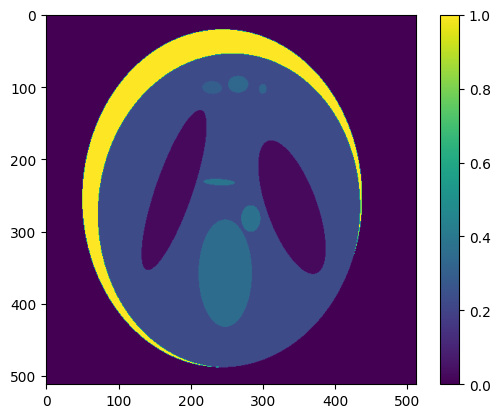

In [6]:
#@title Load Datasets

visualize = True #@param {type:"boolean"}
num_grid_search_samples = 8 #@param
num_test_samples =  8#@param

#@markdown Shepp Dataset
load_shepp = True #@param {type:"boolean"}

datasets = {}
if load_shepp:
    print('Loading Shepp Dataset')
    datasets['shepp'] = get_shepp_dataset(rand_key, num_grid_search_samples, num_test_samples)
    print('Shepp Dataset Loaded')
else: 
    print('Loading ATLAS Dataset')
    datasets['atlas'] = get_atlas_dataset(rand_key, num_grid_search_samples, num_test_samples)
    print('ATLAS Dataset Loaded')

x1 = np.linspace(0, 1, RES+1)[:-1] # use full image resolution 
x_train = np.stack(np.meshgrid(x1,x1), axis=-1)
x_test = x_train

def plot_dataset(dataset):
    plt.imshow(dataset['data_test'][0,:,:])
    plt.colorbar()
    plt.show()

if visualize:
    for dataset in datasets:
        print(f'Dataset {dataset}')
        plot_dataset(datasets[dataset])

# Network setup

In [7]:
#@title Define ReLU Network

network_depth = 4 #@param
network_width = 256 #@param

def make_network(num_layers, num_channels):
  layers = []
  for i in range(num_layers-1):
      layers.append(stax.Dense(num_channels))
      layers.append(stax.Relu)
  layers.append(stax.Dense(1))
  layers.append(stax.Sigmoid)
  return stax.serial(*layers)

init_fn, apply_fn = make_network(network_depth, network_width)

## Setup 2D encoder

Our 2D input embedding is of the form: \
> $\gamma(\mathbf v) = (a_0 \sin(\pi b_0^\top \mathbf v), a_0 \cos(\pi b_0^\top \mathbf v),a_1 \sin(\pi b_1^\top \mathbf v), a_1 \cos(\pi b_1^\top \mathbf v),...)$

This creates a kernel of the form: \
> $k_\gamma(\mathbf v_1, \mathbf v_2) = \sum_{i=1}^m a_i^2 \cos(\pi b_i^\top (\mathbf v_1 - \mathbf v_2))$

In [8]:
#@title Embedding Definitions

embedding_size = 256 #@param

enc_dict = {}

input_encoder = lambda x, a, b: np.concatenate([a * np.sin((2.*np.pi*x) @ b.T), 
                                                a * np.cos((2.*np.pi*x) @ b.T)], axis=-1) #/ np.linalg.norm(a) * np.sqrt(a.shape[0])

def compute_new_posenc(mres):
  bvals = 2.**np.linspace(0,mres,embedding_size//2) - 1.
  bvals = np.stack([bvals, np.zeros_like(bvals)], -1)
  bvals = np.concatenate([bvals, np.roll(bvals, 1, axis=-1)], 0) + 0
  avals = np.ones((bvals.shape[0])) 
  return avals, bvals

def compute_basic():
  bvals = np.eye(2)
  avals = np.ones((bvals.shape[0])) 
  return avals, bvals

def visualize_encoders(enc_dict, keys=None):
    if keys is None:
        keys = enc_dict.keys()

    P = len(keys)
    plt.figure(figsize=(15,5))
    slices = {}
    for i, enc in enumerate(keys):
        plt.subplot(1,P,i+1)
        avals, bvals = enc_dict[enc]
        plt.scatter(bvals[:,0], bvals[:,1], marker='o', s=10, label=enc)
        plt.title(f'{enc} b values')
        plt.axis('equal')
    plt.show()

# CT Projection

In [9]:
@jit
def ct_project(img, theta):
    y, x = np.meshgrid(np.arange(int(img.shape[0]), dtype=np.float32)/int(img.shape[0]) - 0.5, np.arange(int(img.shape[1]), dtype=np.float32)/int(img.shape[1]) - 0.5, indexing='ij')
    x_rot = x*np.cos(theta) - y*np.sin(theta)
    y_rot = x*np.sin(theta) + y*np.cos(theta)
    x_rot = (x_rot + 0.5)*img.shape[1]
    y_rot = (y_rot + 0.5)*img.shape[0]
    sample_coords = np.stack([y_rot, x_rot], axis=0)
    resampled = ndimage.map_coordinates(img, sample_coords, 0).reshape(img.shape)
    return resampled.mean(axis=0)[:,None,...]

ct_project_batch = vmap(ct_project, (None, 0), 0)

# Train Model

In [10]:
run_model = jit(lambda params, x: np.reshape(apply_fn(params, np.reshape(x, (-1, x.shape[-1]))), (x.shape[0], x.shape[1])))
compute_projs = jit(lambda params, x, thetas: ct_project_batch(run_model(params, x), thetas))
model_loss_proj = jit(lambda params, x, y, thetas: .5 * np.mean((compute_projs(params, x, thetas) - y) ** 2))
model_loss = jit(lambda params, x, y, thetas, image: .5 * np.abs(np.mean((np.clip(run_model(params, x), 0.0, 1.0) - image) ** 2)))
model_psnr = jit(lambda params, x, y, thetas, image: -10 * np.log10(2.*model_loss(params, x, y, thetas, image)))
model_grad_loss = jit(lambda params, x, y, thetas, image: grad(model_loss_proj)(params, x, y, thetas))


GROUPS_MODEL = {'Test PSNR':[], 'Train PSNR':[]}
def train_model(lr, iters, train_data, test_data, name='', plot_groups=None):
    opt_init, opt_update, get_params = optimizers.adam(lr)
    opt_update = jit(opt_update)

    _, params = init_fn(rand_key, (-1, train_data[0].shape[-1]))
    opt_state = opt_init(params)

    train_psnrs = []
    test_psnrs = []
    xs = []
    if plot_groups is not None:
        plot_groups['Test PSNR'].append(f'{name}_test')
        plot_groups['Train PSNR'].append(f'{name}_train')
    for i in tqdm(range(iters), desc='train iter', leave=False):
        opt_state = opt_update(i, model_grad_loss(get_params(opt_state), *train_data), opt_state)
        if i % 25 == 0:
            train_psnr = model_psnr(get_params(opt_state), *train_data)
            test_psnr = model_psnr(get_params(opt_state), *test_data)
            train_psnrs.append(train_psnr)
            test_psnrs.append(test_psnr)
            xs.append(i)
            if plot_groups is not None:
                plotlosses_model.update({f'{name}_train':train_psnr, f'{name}_test':test_psnr}, current_step=i)
        if i % 100 == 0 and i != 0 and plot_groups is not None:
            plotlosses_model.send()
    if plot_groups is not None:
        plotlosses_model.send()
    results = {
        'state': get_params(opt_state),
        'train_psnrs': train_psnrs,
        'test_psnrs': test_psnrs,
        'xs': xs,
        'final_test' : run_model(get_params(opt_state), test_data[0])
    }
    return results


def train_gridopt(lr, iters, train_data, test_data, name='', plot_groups=None):
    compute_projs = jit(lambda params, thetas: ct_project_batch(params, thetas))
    model_loss_proj = jit(lambda params, y, thetas: .5 * np.mean((compute_projs(jax.nn.sigmoid(params), thetas) - y) ** 2))
    model_loss = jit(lambda params, y, thetas, image: .5 * np.abs(np.mean((jax.nn.sigmoid(params) - image) ** 2)))
    model_psnr = jit(lambda params, y, thetas, image: -10 * np.log10(2.*model_loss(params, y, thetas, image)))
    model_grad_loss = jit(lambda params, y, thetas, image: grad(model_loss_proj)(params, y, thetas))

    opt_init, opt_update, get_params = optimizers.adam(lr)
    opt_update = jit(opt_update)

    grid = np.zeros((RES, RES))
    opt_state = opt_init(grid)

    train_psnrs = []
    test_psnrs = []
    xs = []
    if plot_groups is not None:
        plot_groups['Test PSNR'].append(f'{name}_test')
        plot_groups['Train PSNR'].append(f'{name}_train')
    for i in tqdm(range(iters), desc='train iter', leave=False):
        opt_state = opt_update(i, model_grad_loss(get_params(opt_state), *train_data), opt_state)
        if i % 25 == 0:
            train_psnr = model_psnr(get_params(opt_state), *train_data)
            test_psnr = model_psnr(get_params(opt_state), *test_data)
            train_psnrs.append(train_psnr)
            test_psnrs.append(test_psnr)
            xs.append(i)
            if plot_groups is not None:
                plotlosses_model.update({f'{name}_train':train_psnr, f'{name}_test':test_psnr}, current_step=i)
        if i % 100 == 0 and i != 0 and plot_groups is not None:
            plotlosses_model.send()
    if plot_groups is not None:
        plotlosses_model.send()
    results = {
        'state': get_params(opt_state),
        'train_psnrs': train_psnrs,
        'test_psnrs': test_psnrs,
        'xs': xs,
        'final_test' : jax.nn.sigmoid(get_params(opt_state))
    }
    return results

In [11]:
#@title CT projection parameters

num_thetas = 20#@param

searching over, [ 2.  3.  4.  5.  6.  7.  8.  9. 10.]


Scale:   0%|          | 0/9 [00:00<?, ?it/s]

Image:   0%|          | 0/8 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

...

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

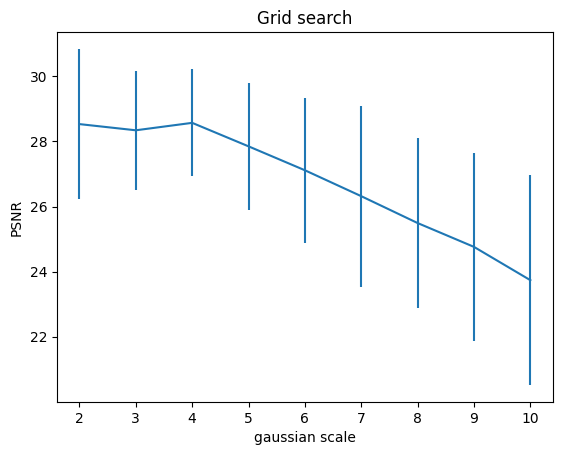

Adding gaussian scale 4.0 to encoding methods


In [17]:
#@title Grid Search Gaussian bval distributions
#@markdown The models are trained on a different set of data. The top distribution is added to the list.

lr =  1e-3#@param
training_steps =  1000#@param
target_distribution = "shepp" #@param ["shepp", "atlas"]
num_images =  8#@param
min_scale =  2#@param
max_scale =  10#@param
num_scales =  9#@param

bvals = random.normal(rand_key, (embedding_size, 2))
avals = np.ones((bvals.shape[0])) 
scales = np.linspace(min_scale, max_scale, num_scales)
print(f'searching over, {scales}')

if num_images == 1:
    plt_groups = {'Test PSNR':[], 'Train PSNR':[]}
    plotlosses_model = PlotLosses(groups=plt_groups)
else:
    plt_groups = None
result_psnrs = []
for scale in tqdm(scales, desc='Scale', leave=False):
    scale_results = []
    for i in tqdm(range(num_images), desc='Image', leave=False):
        image = datasets[target_distribution]['data_grid_search'][i,:,:]
        thetas = np.linspace(0.0, np.pi, num_thetas+1)[:-1]
        # compute projections
        y_train = ct_project_batch(image, thetas)
        y_test = y_train # don't need extra projs for CT (performance is on recon.)
        train_data = (input_encoder(x_train, avals, bvals*scale), y_train, thetas, image)
        test_data = (input_encoder(x_test, avals, bvals*scale), y_test, thetas, image)
        scale_results.append(train_model(lr, training_steps, train_data, test_data, 
                                         name=scale, plot_groups=plt_groups)['test_psnrs'][-1])
    result_psnrs.append(scale_results)

result_psnrs = np.array(result_psnrs)
plt.errorbar(scales, np.mean(result_psnrs, axis=-1), yerr=np.std(result_psnrs, axis=-1))
plt.title('Grid search')
plt.xlabel('gaussian scale')
plt.ylabel('PSNR')
plt.show()

best_scale = scales[np.argmax(np.mean(result_psnrs, axis=-1))]
print(f'Adding gaussian scale {best_scale} to encoding methods')
enc_dict[f'gaussian_{"%.2f" % best_scale}'] = (avals, bvals*best_scale)

searching over, [1 2 3 4 5 6 7]


Scale:   0%|          | 0/7 [00:00<?, ?it/s]

Image:   0%|          | 0/8 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

...

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

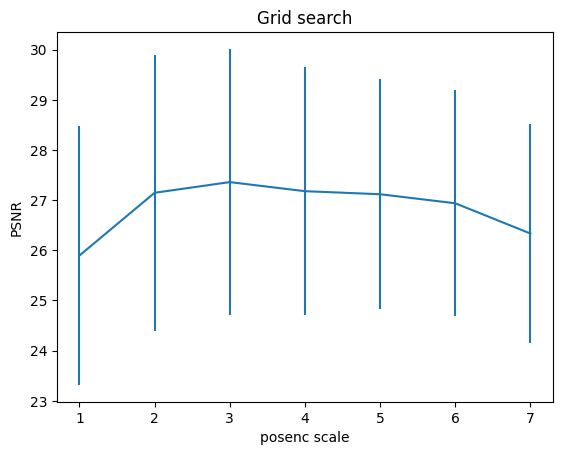

Adding posenc scale 3 to encoding methods


In [19]:
#@title Grid Search posenc distributions
#@markdown The models are trained on a different set of data. The top distribution is added to the list.

lr =  1e-3#@param
training_steps =  1000#@param
target_distribution = "shepp" #@param ["shepp", "atlas"]
num_images =  8#@param
min_scale =  1#@param
max_scale =  7#@param

scales = np.arange(min_scale, max_scale+1)
print(f'searching over, {scales}')

if num_images == 1:
    plt_groups = {'Test PSNR':[], 'Train PSNR':[]}
    plotlosses_model = PlotLosses(groups=plt_groups)
else:
    plt_groups = None
result_psnrs = []
for scale in tqdm(scales, desc='Scale', leave=False):

    avals, bvals = compute_new_posenc(scale)

    scale_results = []
    for i in tqdm(range(num_images), desc='Image', leave=False):
        image = datasets[target_distribution]['data_grid_search'][i,:,:]
        thetas = np.linspace(0.0, np.pi, num_thetas+1)[:-1]
        # compute projections
        y_train = ct_project_batch(image, thetas)
        y_test = y_train # don't need extra projs for CT (performance is on recon.)
        train_data = (input_encoder(x_train, avals, bvals), y_train, thetas, image)
        test_data = (input_encoder(x_test, avals, bvals), y_test, thetas, image)
        scale_results.append(train_model(lr, training_steps, train_data, test_data, 
                                         name=scale, plot_groups=plt_groups)['test_psnrs'][-1])
    result_psnrs.append(scale_results)

result_psnrs = np.array(result_psnrs)
plt.errorbar(scales, np.mean(result_psnrs, axis=-1), yerr=np.std(result_psnrs, axis=-1))
plt.title('Grid search')
plt.xlabel('posenc scale')
plt.ylabel('PSNR')
plt.show()

best_scale = scales[np.argmax(np.mean(result_psnrs, axis=-1))]
print(f'Adding posenc scale {best_scale} to encoding methods')
enc_dict[f'posenc_{"%.2f" % best_scale}'] = compute_new_posenc(best_scale)

In [12]:
import pickle, gzip

#with open('enc_dict.pkl', 'wb') as f:
    #pickle.dump(enc_dict, f)
#print('saved enc_dict with keys:', enc_dict.keys())

def reload_obj(fname: str):
    with open(fname, 'rb') as f:
        obj = pickle.load(f)
    print('loaded obj:', fname)
    return obj

In [13]:
#@title Define Final Experiment Parameters

params = {
    'shepp': {
        'lr': 1e-3,
        'no_enc_lr': 1e-2,
        'basic_lr': 1e-2,
        'gridopt_lr': 1e-1,
        'posenc_scale': 3,
        'gaussian_scale': 4,
    },
    'atlas': {
        'lr': 1e-3,
        'no_enc_lr': 1e-2,
        'basic_lr': 1e-2,
        'gridopt_lr': 1e-1,
        'posenc_scale': 5,
        'gaussian_scale': 5,
    },
    'dog': {
        'lr': 5e-4,
        'no_enc_lr': 1e-2,
        'basic_lr': 5e-3,
        'gridopt_lr': 1e-1,
        'posenc_scale': 4,
        'gaussian_scale': 6,
    },
    'black_hole': {
        'lr': 5e-4,
        'no_enc_lr': 1e-2,
        'basic_lr': 5e-3,
        'gridopt_lr': 1e-2,
        'posenc_scale': 3,
        'gaussian_scale': 4,
    }
}

In [22]:
#@title Train Models

training_steps =  1000#@param

target_distribution = "shepp" #@param ["shepp", "atlas"]

num_images =  8#@param

if num_images == 1:
    plt_groups = {'Test PSNR':[], 'Train PSNR':[]}
    plotlosses_model = PlotLosses(groups=plt_groups)
else:
    plt_groups = None

thetas = np.linspace(0.0, np.pi, num_thetas+1)[:-1]

outputs = {}

# no encoding
lr = params[target_distribution]['no_enc_lr']
outputs['no_encoding'] = []
for i in tqdm(range(num_images), desc='no encoding', leave=False):
  image = datasets[target_distribution]['data_test'][i,:,:]
  # compute projections
  y_train = ct_project_batch(image, thetas)
  y_test = y_train # don't need extra projs for CT (performance is on recon.)
  outputs['no_encoding'].append(train_model(lr, training_steps, 
                                            (x_train, y_train, thetas, image), 
                                            (x_test, y_test, thetas, image), 
                                            name='no_encoding', plot_groups=plt_groups))
  

# basic encoding 
avals, bvals = compute_basic()
lr = params[target_distribution]['basic_lr']
outputs['basic'] = []
for i in tqdm(range(num_images), desc='basic', leave=False):
  image = datasets[target_distribution]['data_test'][i,:,:]
  # compute projections
  y_train = ct_project_batch(image, thetas)
  y_test = y_train # don't need extra projs for CT (performance is on recon.)
  train_data = (input_encoder(x_train, avals, bvals), y_train, thetas, image)
  test_data = (input_encoder(x_test, avals, bvals), y_test, thetas, image)
  outputs['basic'].append(train_model(lr, training_steps, train_data, test_data, name='basic', plot_groups=plt_groups))


# new posenc 
avals, bvals = compute_new_posenc(params[target_distribution]['posenc_scale'])
lr = params[target_distribution]['lr']
outputs['new_posenc'] = []
for i in tqdm(range(num_images), desc='new posenc', leave=False):
  image = datasets[target_distribution]['data_test'][i,:,:]
  # compute projections
  y_train = ct_project_batch(image, thetas)
  y_test = y_train # don't need extra projs for CT (performance is on recon.)
  train_data = (input_encoder(x_train, avals, bvals), y_train, thetas, image)
  test_data = (input_encoder(x_test, avals, bvals), y_test, thetas, image)
  outputs['new_posenc'].append(train_model(lr, training_steps, train_data, test_data, name='new_posenc', plot_groups=plt_groups))


# gaussian
bvals = random.normal(rand_key, (embedding_size, 2)) * params[target_distribution]['gaussian_scale']
avals = np.ones((bvals.shape[0])) 
lr = params[target_distribution]['lr']
outputs['gaussian'] = []
for i in tqdm(range(num_images), desc='gaussian', leave=False):
  image = datasets[target_distribution]['data_test'][i,:,:]
  # compute projections
  y_train = ct_project_batch(image, thetas)
  y_test = y_train # don't need extra projs for CT (performance is on recon.)
  train_data = (input_encoder(x_train, avals, bvals), y_train, thetas, image)
  test_data = (input_encoder(x_test, avals, bvals), y_test, thetas, image)
  outputs['gaussian'].append(train_model(lr, training_steps, train_data, test_data, name='gaussian', plot_groups=plt_groups))


# grid optimization baseline
outputs['gridopt'] = []
lr = params[target_distribution]['gridopt_lr']
for i in tqdm(range(num_images), desc='gridopt', leave=False):
  image = datasets[target_distribution]['data_test'][i,:,:]
  # compute projections
  y_train = ct_project_batch(image, thetas)
  y_test = y_train # don't need extra projs for CT (performance is on recon.)
  train_data = (y_train, thetas, image)
  test_data = train_data
  outputs['gridopt'].append(train_gridopt(lr, training_steps, train_data, test_data, name='gridopt', plot_groups=plt_groups))

no encoding:   0%|          | 0/8 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

...

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

train iter:   0%|          | 0/1000 [00:00<?, ?it/s]

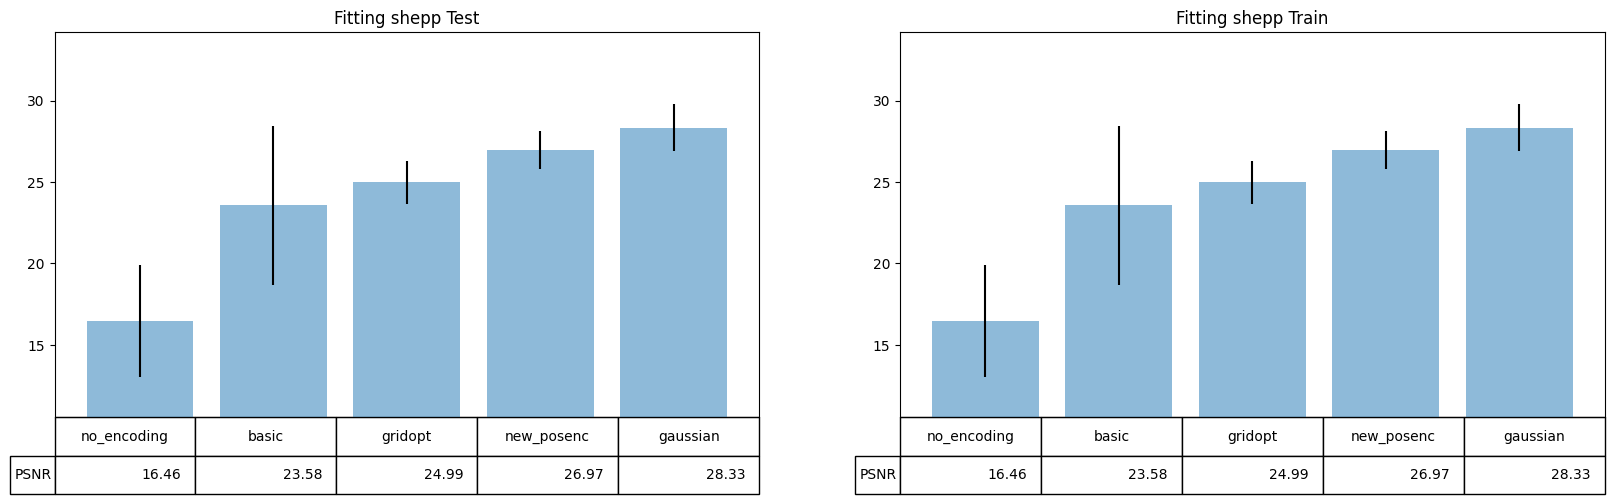

----------------------------------------
                  Test
----------------------------------------


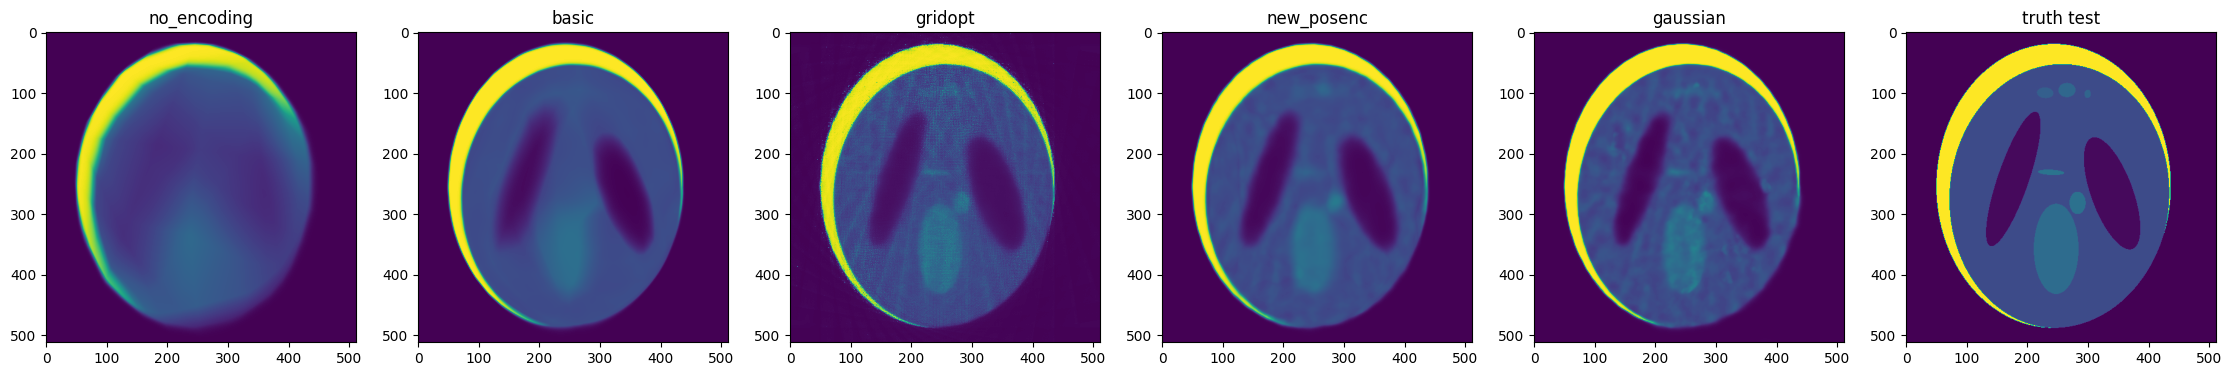

In [23]:
#@title Plot Results

bar_graph = True #@param {type:"boolean"}
image_reconstructions = True #@param {type:"boolean"}
test_img_id =  0#@param

names = list(outputs.keys())

image_test = datasets[target_distribution]['data_test'][test_img_id,:,:]

xvals = np.arange(len(names))
test_values = np.array([[outputs[n][i]['test_psnrs'][-1] for i in range(len(outputs[n]))] for n in names])
test_values_mean = np.mean(test_values, axis=-1)
test_values_std = np.std(test_values, axis=-1)
train_values = np.array([[outputs[n][i]['train_psnrs'][-1] for i in range(len(outputs[n]))] for n in names])
train_values_mean = np.mean(train_values, axis=-1)
train_values_std = np.std(train_values, axis=-1)
inds = np.argsort(test_values_mean)
names_sort = [names[i] for i in inds]

if bar_graph:
    plt.figure(figsize=(20,5))
    plt.subplot(1,2,1)
    plt.bar(xvals+2, test_values_mean[inds], color=colors[0], alpha=.5, yerr=test_values_std)
    plt.xticks([])
    plt.ylim(test_values_mean.min()-test_values_std.max()-1, test_values_mean.max()+test_values_std.max()+1)
    plt.title(f'Fitting {target_distribution} Test')
    prnt_vals = ['%.2f' % x for x in test_values_mean[inds].tolist()]
    plt.table(cellText=[prnt_vals], 
              rowLabels=['PSNR'], 
              colLabels=names_sort, 
              loc='bottom', 
              bbox=[0, -.2, 1, 0.2])

    plt.subplot(1,2,2)
    plt.bar(xvals, train_values_mean[inds], color=colors[0], alpha=.5, yerr=train_values_std)
    # plt.xticks(xvals, names_sort, rotation=60)
    plt.xticks([])
    plt.ylim(train_values_mean.min()-train_values_std.max()-1, train_values_mean.max()+train_values_std.max()+1)
    plt.title(f'Fitting {target_distribution} Train')
    plt.table(cellText=[['%.2f' % x for x in train_values_mean[inds].tolist()]],
        rowLabels=['PSNR'],
        colLabels=names_sort,
        loc='bottom',
        bbox=[0, -.2, 1, 0.2])
    
    plt.show()

if image_reconstructions:
    print('----------------------------------------')
    print('                  Test')
    print('----------------------------------------')
    plt.figure(figsize=(28,6))
    for i, p in enumerate(names_sort):
        pred = outputs[p][0]['final_test']
        plt.subplot(1,len(names)+1,i+1)
        plt.imshow(pred)
        plt.title(p)

    plt.subplot(1,len(names)+1,len(names)+1)
    plt.imshow(image_test)
    plt.title('truth test')
    plt.show()

In [26]:
np.savez('2D_CT_shepp.npz', outputs)

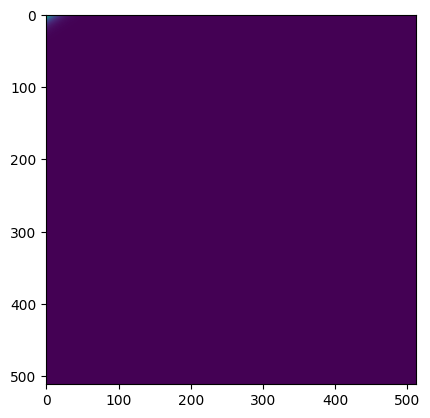

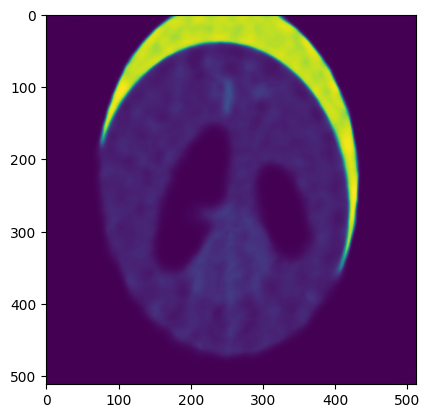

In [25]:
ind = 6
pred_ne = outputs['no_encoding'][ind]['final_test']
pred_g = outputs['gaussian'][ind]['final_test']
plt.figure()
plt.imshow(pred_ne)
plt.figure()
plt.imshow(pred_g)

In [27]:
plt.imsave('2D_CT_no_encoding.png', pred_ne, cmap='gray')
plt.imsave('2D_CT_gaussian_encoding.png', pred_g, cmap='gray')

Welcome to eht-imaging! v 1.2.10 

Loading text image:  ../datasets/avery_sgra_eofn.txt
(512, 512) float32
0.001427071 1.0


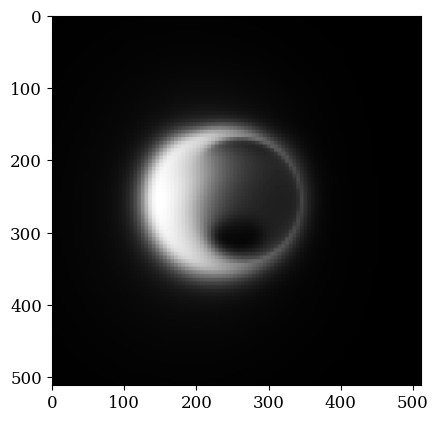

In [14]:
import io
from PIL import Image
import ehtim as eh
def fetch_photo_slice(filename: str = ''):
    """
    Download a single iNaturalist photo and return a (RES, RES) float32 array
    scaled to [0,1].  Optionally writes the JPEG to disk.
    """
    if ".txt" in filename:
        image_true = eh.image.load_txt(filename)
        
        arr = np.array(image_true.imarr(), dtype=np.float32)
        arr = resize(arr, (RES, RES)) / arr.max()
    else:
        img = Image.open(filename).convert("L")
        arr = np.asarray(img, dtype=np.float32) 
        arr = resize(arr, (RES, RES)) / 255.0

    print(arr.shape, arr.dtype)
    plt.imshow(arr, cmap='gray')
    print(arr.min(), arr.max())
    return arr

image = fetch_photo_slice(filename="../datasets/avery_sgra_eofn.txt")

In [15]:
target_distribution = "black_hole"

if not enc_dict:
    enc_dict = reload_obj('enc_dict.pkl')

bvals = random.normal(rand_key, (embedding_size, 2)) * params[target_distribution]['gaussian_scale']
avals = np.ones((bvals.shape[0])) 
training_steps =  5000#@param

num_images =  1#@param
plt_groups = None

def train_new_net_or_fetch_old(retrain: bool, num_thetas: int = 20):
    if not retrain:
        params_img_frozen = np.load('2D_CT_shepp.npz', allow_pickle=True)
        params_img_frozen = params_img_frozen['arr_0'].item()
        print("loaded outputs dict with keys:", params_img_frozen.keys())
        params_img_frozen = params_img_frozen['gaussian'][0]['state']
        thetas = np.linspace(0.0, np.pi, 20+1)[:-1]
        return (thetas, params_img_frozen)
    else:
        if target_distribution == "starfish":
            image = fetch_photo_slice(filename="starfish.png")
        elif target_distribution == "black_hole":
            image = fetch_photo_slice(filename="../datasets/avery_sgra_eofn.txt")
        else: 
            image = datasets[target_distribution]['data_test'][0,:,:]
        print('Training new network with num_thetas:', num_thetas)

        thetas = np.linspace(0.0, np.pi, num_thetas+1)[:-1]
        lr = params["black_hole"]['lr']
        # compute projections
        y_train = ct_project_batch(image, thetas)
        y_test = y_train # don't need extra projs for CT (performance is on recon.)
        train_data = (input_encoder(x_train, avals, bvals), y_train, thetas, image)
        test_data = (input_encoder(x_test, avals, bvals), y_test, thetas, image)
        return (thetas, train_model(lr, training_steps, train_data, test_data, name='gaussian', plot_groups=plt_groups)['state'])


loaded obj: enc_dict.pkl


In [16]:
from flax import linen as nn
import functools

def bilinear(coords, theta):
    gx, gy, _ = theta.shape
    # scale to vertex index space
    x = coords[..., 0] * (gx - 1)
    y = coords[..., 1] * (gy - 1)

    i0 = np.floor(x).astype(np.int32)
    j0 = np.floor(y).astype(np.int32)
    i1 = np.clip(i0 + 1, 0, gx - 1)
    j1 = np.clip(j0 + 1, 0, gy - 1)

    wx = x - i0
    wy = y - j0

    # gather four corners
    t00 = theta[i0, j0]      # lower-left
    t10 = theta[i1, j0]      # lower-right
    t01 = theta[i0, j1]      # upper-left
    t11 = theta[i1, j1]      # upper-right

    return ((1 - wx) * (1 - wy))[..., None] * t00 + \
           (     wx  * (1 - wy))[..., None] * t10 + \
           ((1 - wx) *      wy )[..., None] * t01 + \
           (     wx  *      wy )[..., None] * t11

class DeformationGrid(nn.Module):
    resolution: tuple[int, ...]

    @nn.compact
    def __call__(self, coords):
        theta = self.param(
            'theta', 
            nn.initializers.zeros, 
            self.resolution + (coords.shape[-1],)
        )
        return bilinear(coords, theta)




Training with num_thetas: 20
Loading text image:  ../datasets/avery_sgra_eofn.txt
(512, 512) float32
0.001427071 1.0
Training new network with num_thetas: 40


train iter:   0%|          | 0/5000 [00:00<?, ?it/s]

----------------------------------------
TARGET DISTRIBUTION: black_hole
USING GRID RESOLUTION: (64, 64)
NUMBER OF DEFORMATION GRID PARAMETERS: 8192
RAYS: 40
NUMBER OF VISIBILITIES: 20480


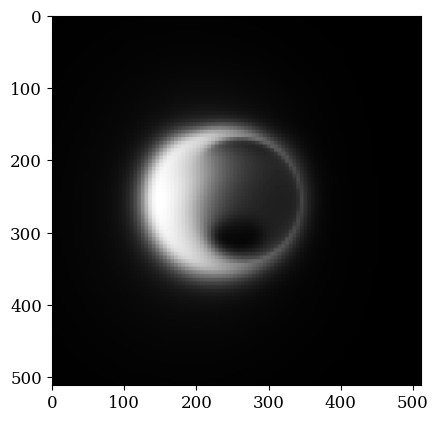

In [17]:

print(f"Training with num_thetas: {num_thetas}")    
num_thetas = 40 #normal is 20
thetas, params_img_frozen = train_new_net_or_fetch_old(retrain=True, num_thetas=num_thetas)
grid_res = (64, 64)
def_grid = DeformationGrid(grid_res)

params_def = def_grid.init(
    jax.random.PRNGKey(0),
    np.array([[0, 0]]))['params']
params_def = jax.tree_util.tree_map(np.zeros_like, params_def)


coords = x_train
coords_enc = input_encoder(coords, avals, bvals)

nvis = num_thetas * RES  #20 rays * RES pixels -> 10240 visibilities
P = 2 * grid_res[0]**2
print("-"*40)
print("TARGET DISTRIBUTION:", target_distribution)
print("USING GRID RESOLUTION:", grid_res)
print("NUMBER OF DEFORMATION GRID PARAMETERS:", P)
print("RAYS:", num_thetas)
print("NUMBER OF VISIBILITIES:", nvis)

In [18]:
def forward_with_deform(params_def, i_theta, j_col, coords_raw, avals, bvals, params_img):
    displacement = def_grid.apply({'params': params_def}, coords_raw)
    coords_deformed = coords_raw + displacement
    enc_def = input_encoder(coords_deformed, avals, bvals)
    img = run_model(params_img, enc_def)
    return ct_project(img, thetas[i_theta])[:, 0][j_col]
                
def flatten(tree):
    return np.concatenate([t.ravel() for t in jax.tree_util.tree_leaves(tree)])

def grad_row(params_def, i_theta, j_col, coords_raw, avals, bvals, params_img):
    g_tree = jax.grad(forward_with_deform, argnums=0)(params_def, i_theta, j_col, 
                                            coords_raw,
                                            avals,
                                            bvals,
                                            params_img)
    return flatten(g_tree['theta'])

@jax.jit
def chunk(params_def, i_theta, j_col, coords_raw, avals, bvals, params_img):
    J = jax.vmap(grad_row, in_axes=(None, 0, 0, None, None, None, None))(params_def, i_theta, j_col, 
                                                                                coords_raw, 
                                                                                avals, 
                                                                                bvals, 
                                                                                params_img)
    return np.sum(J**2, axis=0)

def fisher_sum(chunk_size, coords_raw, avals, bvals, params_def, params_img):
    """
    Args:
        chunk_size: number of rows of the jacobian to evaluate in one step
        res: grid resolution, (xdim, ydim); 2D for now
    Returns:
        J_sq: = sum( (J_re_n^2 + J_im_n^2) / sigma_n^2)
    """
    diag = np.zeros((P,))
    for start in tqdm(range(0, nvis, chunk_size), desc='chunk number'):
        end = min(start + chunk_size, nvis)
        idx = np.arange(start, end)
        
        i_theta = idx // RES
        j_col = idx % RES

        diag += chunk(params_def, i_theta, j_col, 
                    coords_raw, 
                    avals, bvals, 
                    params_img)
    return diag


In [19]:
H = fisher_sum(chunk_size=2, coords_raw=coords, avals=avals, bvals=bvals,
               params_def=params_def, params_img=params_img_frozen,)
H = H/nvis
lam = 1e-8/(grid_res[0]**2)
#lam = 0.5*0.02*jnp.median(H)
print("lambda:", lam)
#print(jnp.linalg.cond(H))
H = H + 2*lam
V = 1/H

chunk number:   0%|          | 0/10240 [00:00<?, ?it/s]

lambda: 2.44140625e-12


In [23]:
gx, gy = grid_res
def flat_idx(i, j, channel): # channel=0(x) or 1(y)
    return 2 * (i*gy + j) + channel

@jax.jit
def build_W_and_idx(u):
    """
    Build the bilinear weight matrix and neighboring weight indicies for effective batching so we dont OOM
    Note that the batching is deterministic. 
    """
    ux, uy = u
    x = ux * (gx-1)
    y = uy * (gy-1)
    i0, j0 = np.floor(x).astype(int), np.floor(y).astype(int)
    i1, j1 = np.minimum(i0+1, gx-1), np.minimum(j0+1, gy-1)
    wx, wy = x - i0, y - j0

    # four vertex weights
    w  = np.array([
        (1-wx)*(1-wy),
        wx *(1-wy),
        (1-wx)*wy,
        wx *wy,
    ])
    idx = np.array([
        flat_idx(i0,j0,0), flat_idx(i0,j0,1),
        flat_idx(i1,j0,0), flat_idx(i1,j0,1),
        flat_idx(i0,j1,0), flat_idx(i0,j1,1),
        flat_idx(i1,j1,0), flat_idx(i1,j1,1),
    ]) # length-8

    #sigma_sub = V[idx[:,None], idx[None,:]]  # (8,8) sub matrix of neighboring bilinear interpolation weights
    W = np.stack([ # 2×8
        np.reshape(np.repeat(w,2)[0::2], (4,)), # x-weights
        np.reshape(np.repeat(w,2)[1::2], (4,)), # y-weights
    ], axis=0).repeat(2, axis=1)[:,:8]
    
    return idx, W
    '''C = W @ sigma_sub @ W.T
    return jnp.sqrt(jnp.trace(C))'''

def make_unc_fn(Sigma):
    """
    Function to handle both a diagonal and full hessian computation.
    Later, we compare the diagonal with the full hessian.
    """
    is_diag = Sigma.ndim==1

    @jax.jit
    def pixel_sigma(u):
        idx, W = build_W_and_idx(u)
        if is_diag:
            sigma_sub = np.diag(Sigma[idx])
        else:
            sigma_sub = Sigma[idx[:,None], idx[None,:]]
        return np.sqrt(np.trace(W @ sigma_sub @ W.T))
    return pixel_sigma

# vectorise over pixels in manageable chunks
def sigma_map_from_coords(coords, Sigma, chunk=8192): 
    """
    compute the full uncertainty map from bayes rays, evaluating at 
    each point in coords
    """
    c_flat = coords.reshape(-1,2)
    unc_fn = make_unc_fn(Sigma)
    out = []
    for k in range(0, c_flat.shape[0], chunk):
        out.append(jax.vmap(unc_fn)(c_flat[k:k+chunk]))
    return np.concatenate(out).reshape(coords.shape[:2])

def plot_uncertainty_figs(sigma_map, log_scaled: bool, save_fig: bool, parent_dir: str, bilinear: bool=False):
    fig, ax = plt.subplots(1, 2, figsize=(20,10))
    full_image = run_model(params_img_frozen, input_encoder(x_train, avals, bvals))
    im_1 = ax[1].imshow(full_image, origin='upper')
    ax[1].set_title('Image inpaint prediction')
    
    thresh = 0.1
    mask = (full_image < thresh)
    sigma_map_clip = np.where(mask, 0.0, sigma_map)

    if log_scaled:
        im_0 = ax[0].imshow(np.log10(sigma_map + 1e-12), cmap='plasma', origin="upper")
        ax[0].set_title(f"Uncertainty map (log scaled)\ndataset={target_distribution}, grid res={grid_res}, rays={num_thetas}")
    else: 
        p98 = np.percentile(sigma_map, 98)
        p2 = np.percentile(sigma_map, 2)

        im_0 = ax[0].imshow(sigma_map, vmin=p2, vmax=p98, cmap='plasma', origin="upper")
        ax[0].set_title(f"Uncertainty map (5th-90th percentile)\npercentile, grid res={grid_res}, dataset={target_distribution}")


    plt.tight_layout()
    suffix = 'bilinear' if bilinear else ''
    for a, im in zip(ax, (im_0, im_1)):
        fig.colorbar(im, ax=a)
    if save_fig:
        plt.savefig(f'{parent_dir}/dataset{target_distribution}_grid_res{grid_res[0]}x{grid_res[1]}_posencgaussian_rays{num_thetas}_{suffix}.png')
    fig, ax = plt.subplots(1,1)
    im = ax.imshow(np.log10(sigma_map+1e-12), cmap='plasma', origin='upper')
    ax.set_title("log$_{10}$ uncertainty map (CT)")
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='3.5%', pad=0.2)
    fig.colorbar(im, cax=cax)
    fig.tight_layout()
    fig.show()
    return sigma_map


UNCERTAINTY MAP SAVED TO: ct_unc_results/


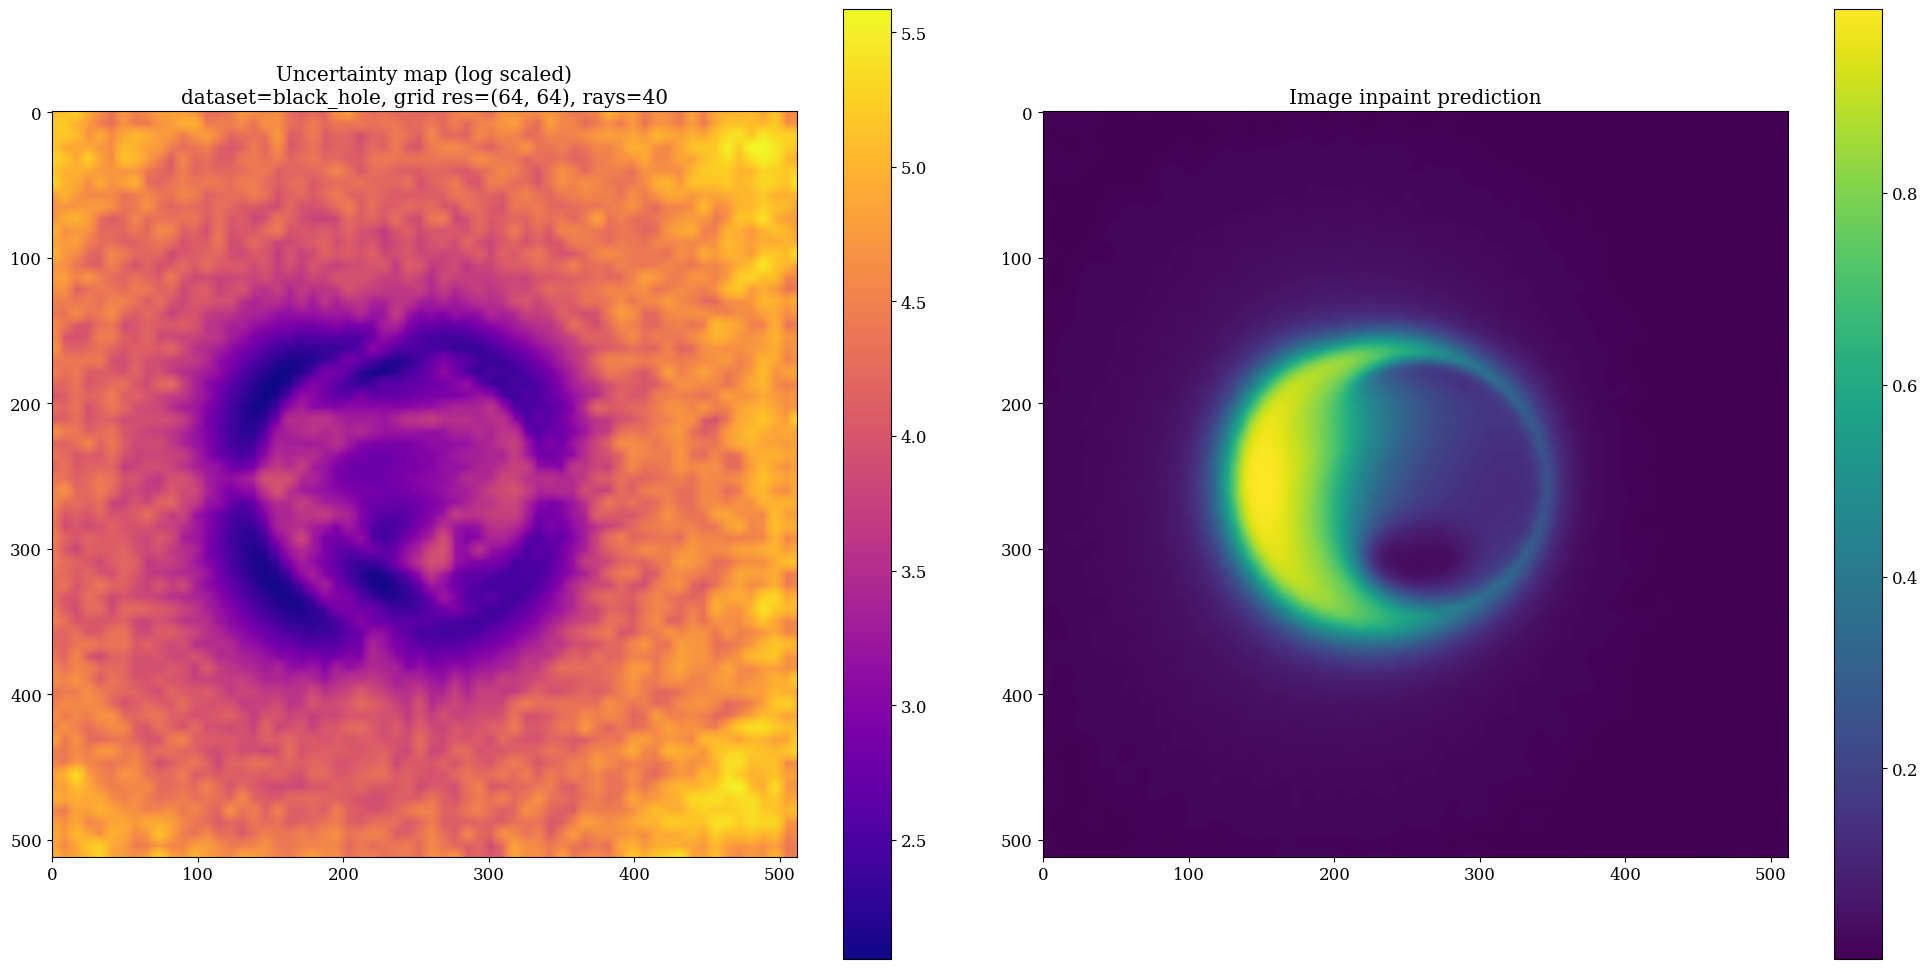

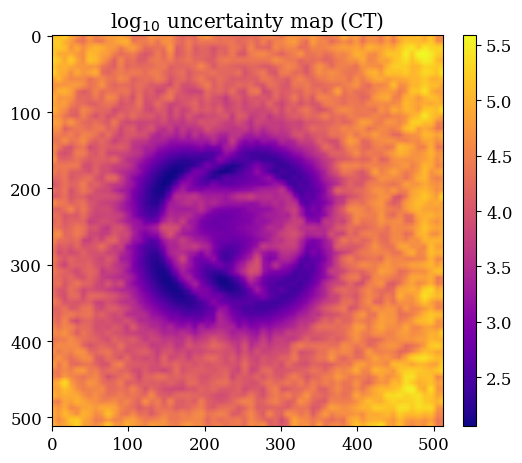

In [24]:
grid_coords = np.stack(np.meshgrid(np.linspace(0, 1, gx), np.linspace(0, 1, gy), indexing='xy'), axis=-1)
sigma_map = sigma_map_from_coords(grid_coords, V).reshape(gx, gy)
sigma_map = bilinear(x_train[...,::-1], sigma_map[..., None]).squeeze(-1)

parent_dir = 'ct_unc_results'
plot_uncertainty_figs(sigma_map, True, True, parent_dir=parent_dir)
print(f"UNCERTAINTY MAP SAVED TO: {parent_dir}/")

train_num:   0%|          | 0/5 [00:00<?, ?it/s]

Training with num_thetas: 2
Loading text image:  ../datasets/avery_sgra_eofn.txt
(512, 512) float32
0.001427071 1.0
Training new network with num_thetas: 2


train iter:   0%|          | 0/5000 [00:00<?, ?it/s]

----------------------------------------
TARGET DISTRIBUTION: black_hole
USING GRID RESOLUTION: (64, 64)
NUMBER OF DEFORMATION GRID PARAMETERS: 8192
RAYS: 2
NUMBER OF VISIBILITIES: 1024
COMPUTING HESSIAN


chunk number:   0%|          | 0/512 [00:00<?, ?it/s]

...

lambda: 2.44140625e-12
UNCERTAINTY MAP SAVED TO: ct_unc_results/
Training with num_thetas: 40
Loading text image:  ../datasets/avery_sgra_eofn.txt
(512, 512) float32
0.001427071 1.0
Training new network with num_thetas: 40


train iter:   0%|          | 0/5000 [00:00<?, ?it/s]

----------------------------------------
TARGET DISTRIBUTION: black_hole
USING GRID RESOLUTION: (64, 64)
NUMBER OF DEFORMATION GRID PARAMETERS: 8192
RAYS: 40
NUMBER OF VISIBILITIES: 20480
COMPUTING HESSIAN


chunk number:   0%|          | 0/10240 [00:00<?, ?it/s]

lambda: 2.44140625e-12
UNCERTAINTY MAP SAVED TO: ct_unc_results/


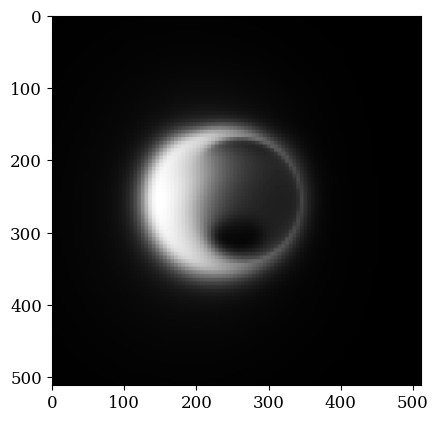

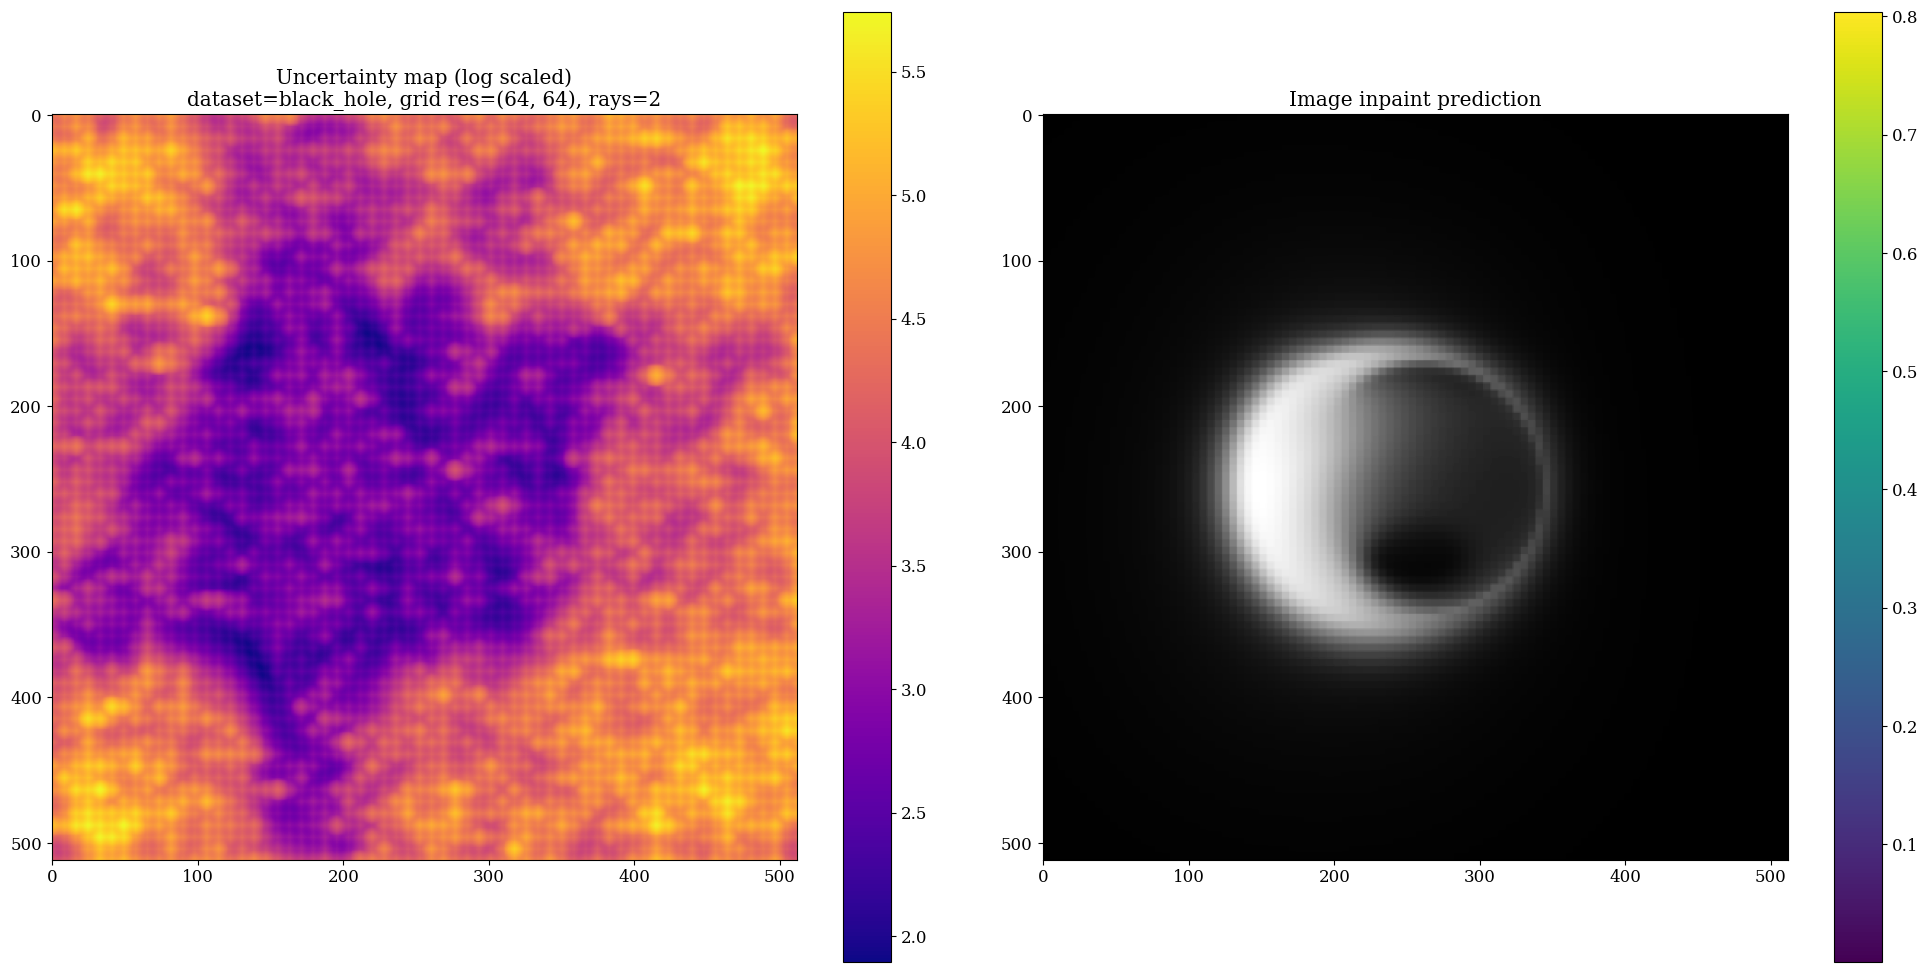

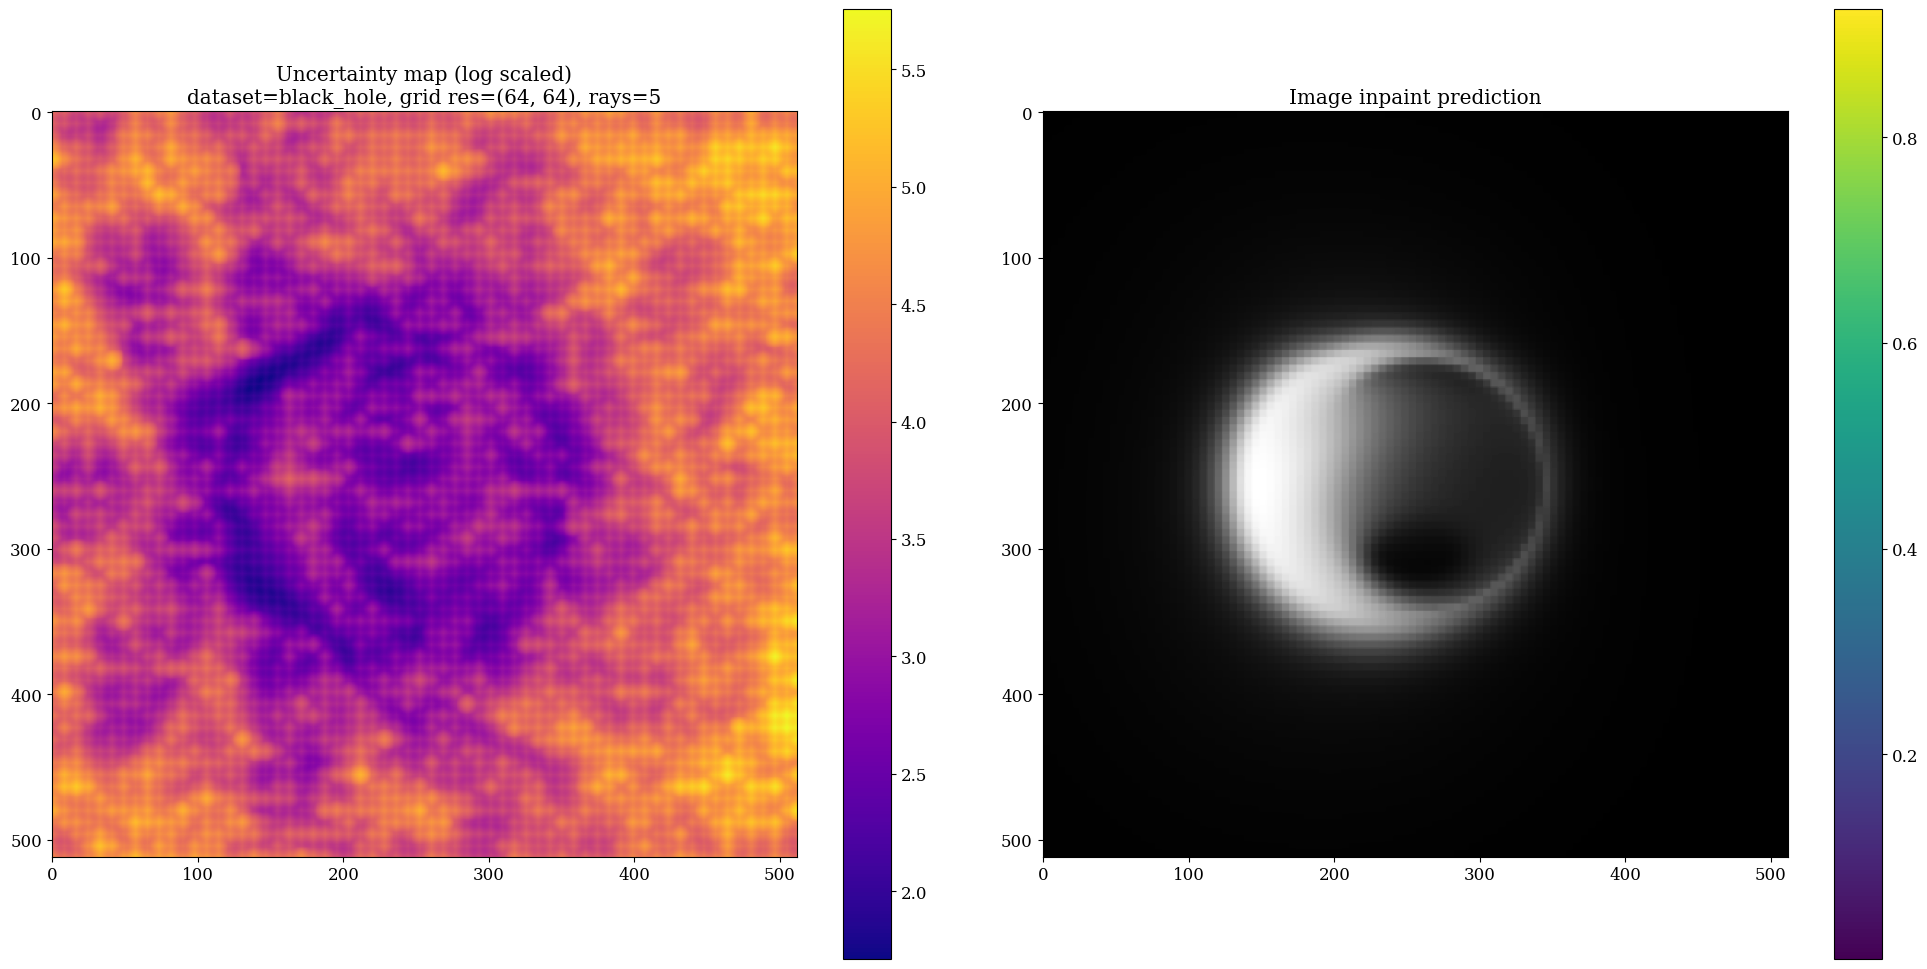

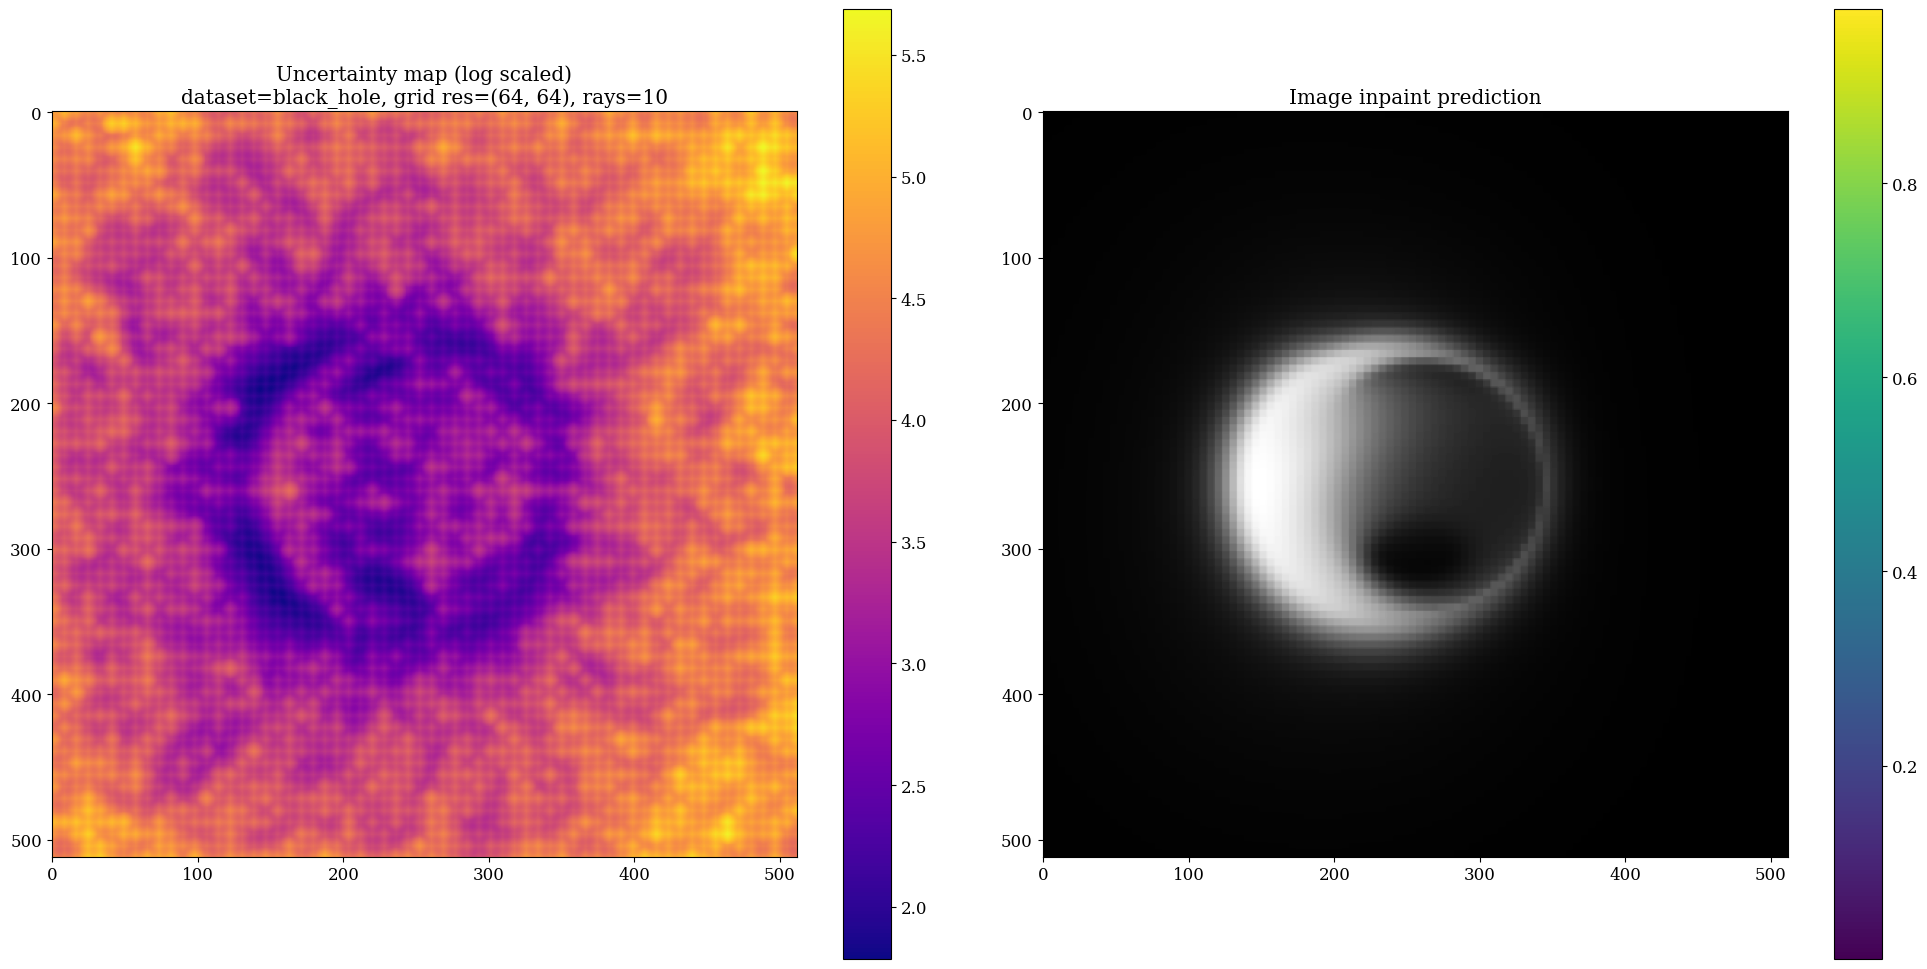

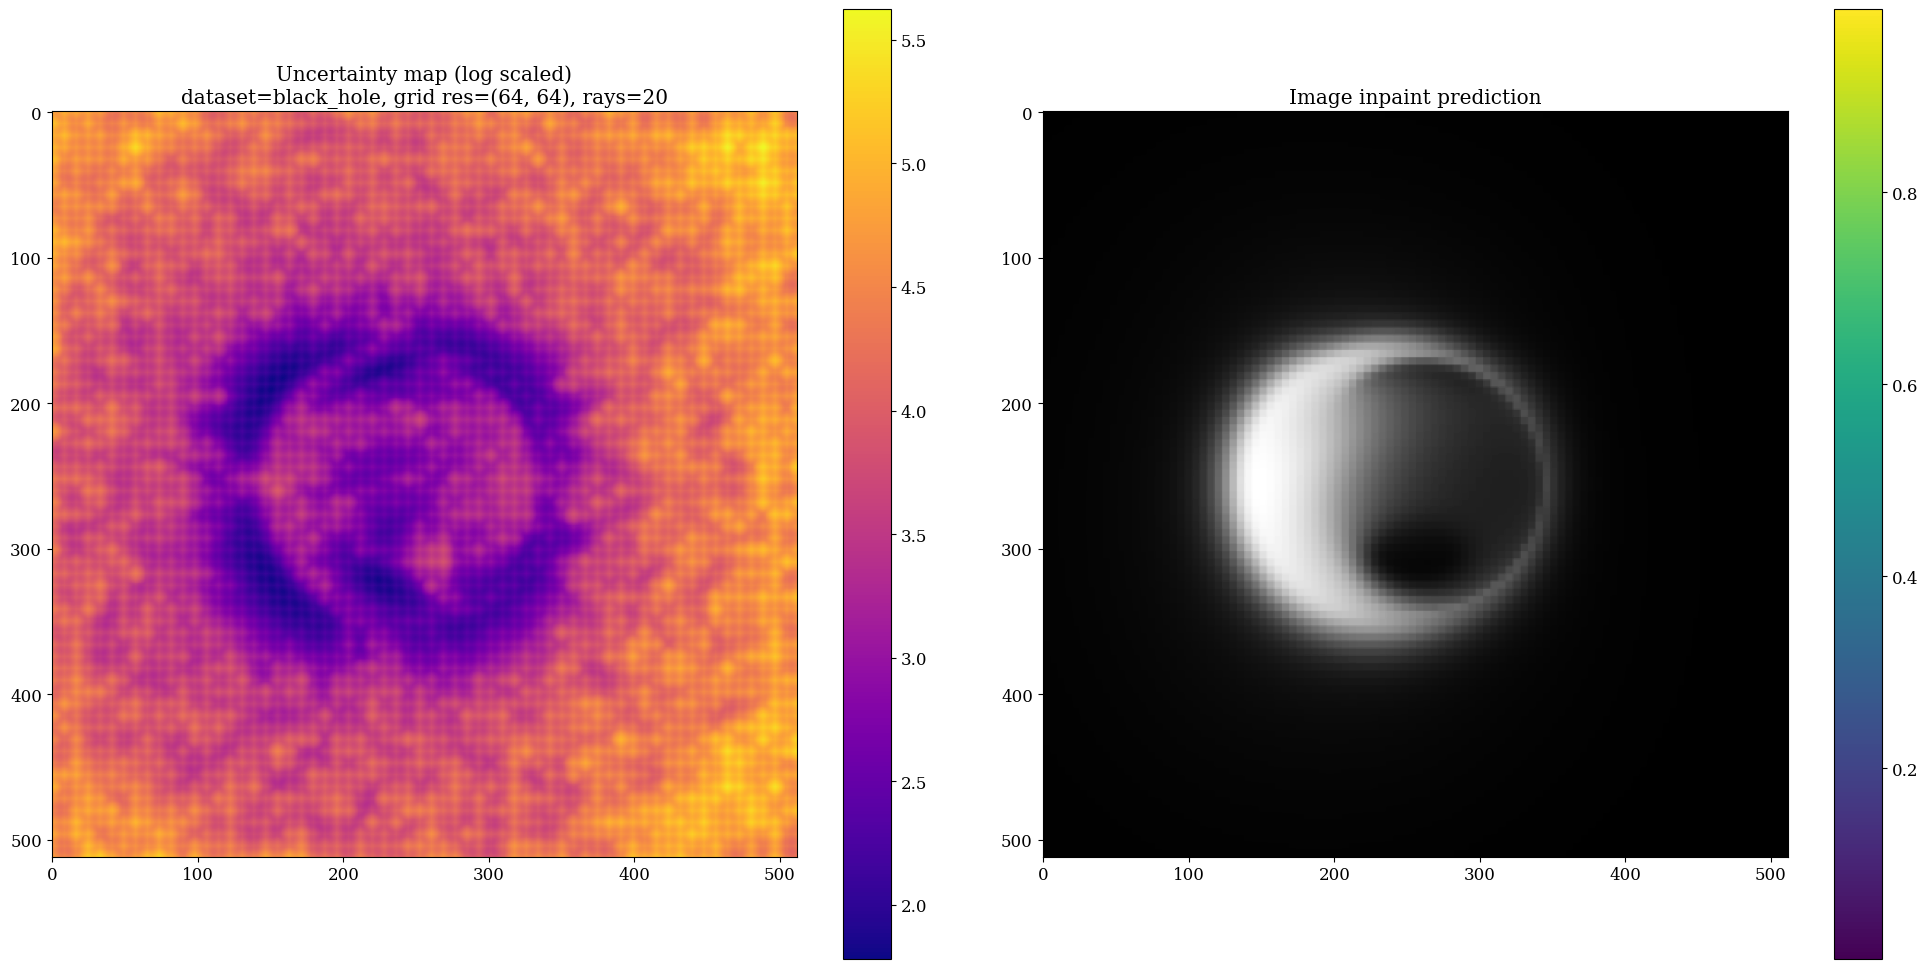

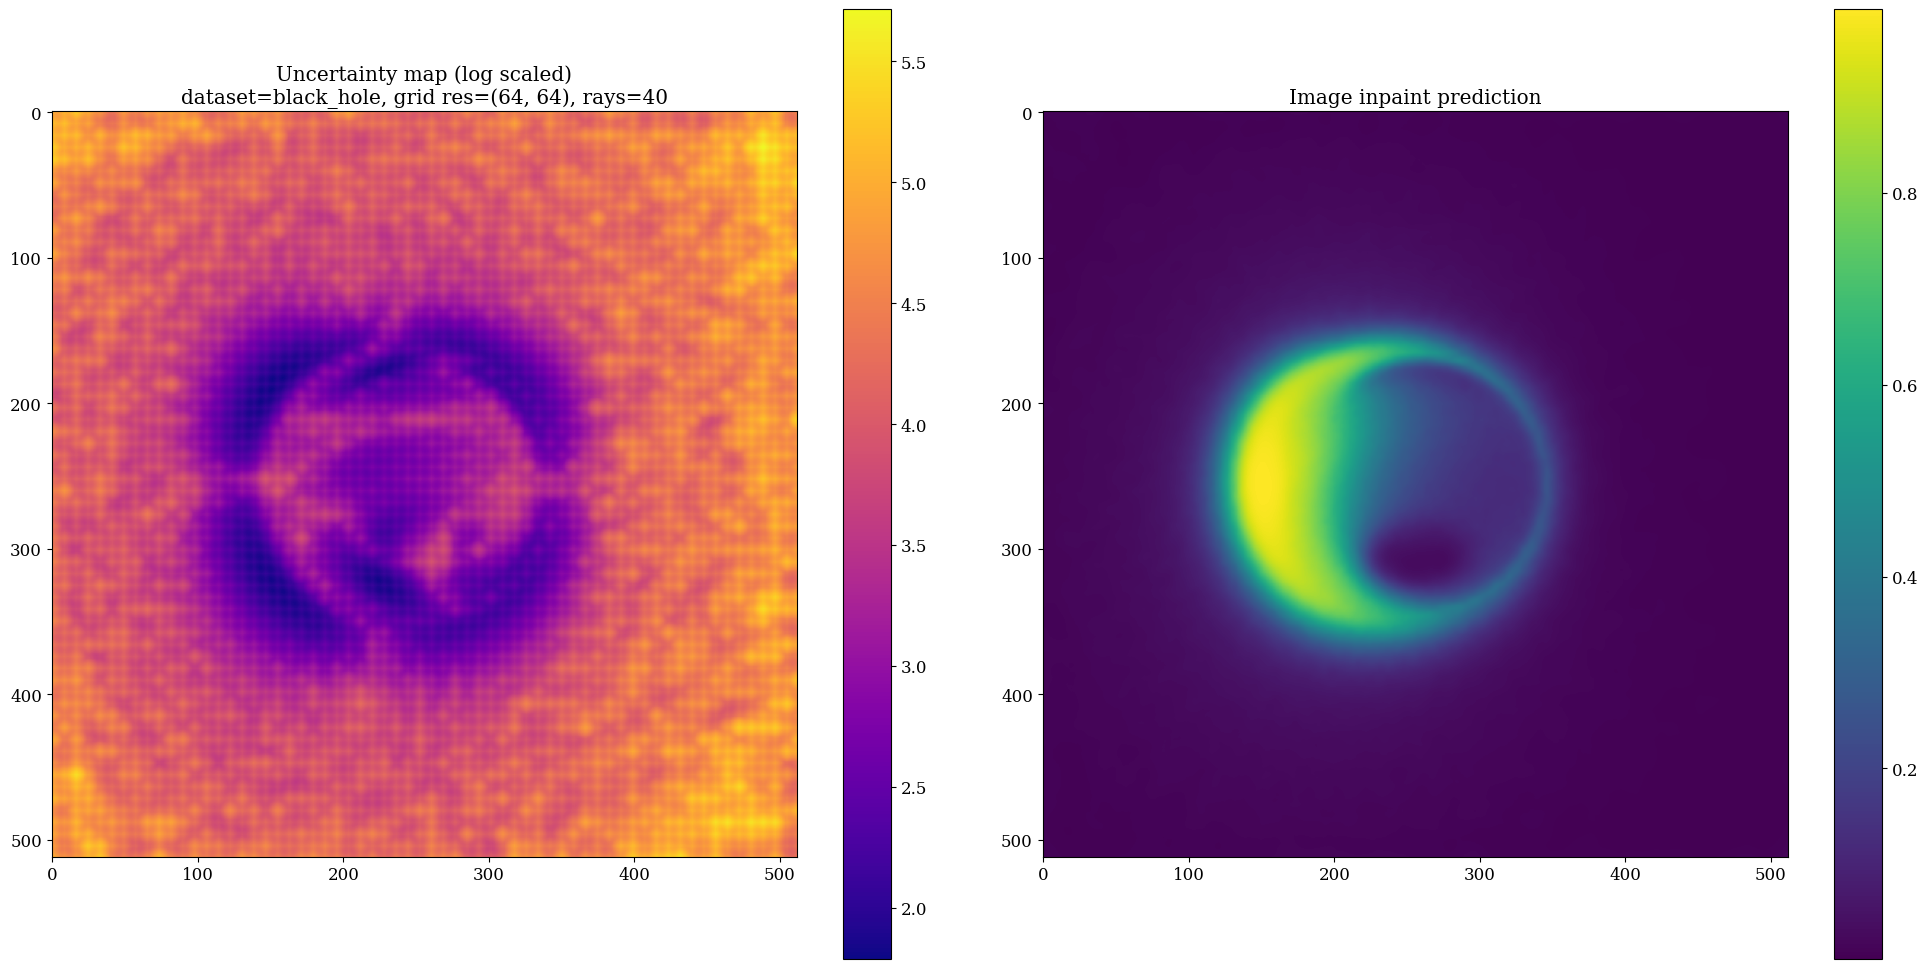

In [46]:
for num_thetas in tqdm([2, 5, 10, 20, 40], desc='train_num'):
    print(f"Training with num_thetas: {num_thetas}")    
    thetas, params_img_frozen = train_new_net_or_fetch_old(retrain=True, num_thetas=num_thetas)
    grid_res = (64, 64)
    def_grid = DeformationGrid(grid_res)

    params_def = def_grid.init(
        jax.random.PRNGKey(0),
        np.array([[0, 0]]))['params']
    params_def = jax.tree_util.tree_map(np.zeros_like, params_def)

    coords = x_train
    coords_enc = input_encoder(coords, avals, bvals)

    nvis = num_thetas * RES  #20 rays * RES pixels -> 10240 visibilities
    P = 2 * grid_res[0]**2
    print("-"*40)
    print("TARGET DISTRIBUTION:", target_distribution)
    print("USING GRID RESOLUTION:", grid_res)
    print("NUMBER OF DEFORMATION GRID PARAMETERS:", P)
    print("RAYS:", num_thetas)
    print("NUMBER OF VISIBILITIES:", nvis)

    print("COMPUTING HESSIAN")
    H = fisher_sum(chunk_size=2, coords_raw=coords, avals=avals, bvals=bvals,
               params_def=params_def, params_img=params_img_frozen,)
    H = H/nvis
    lam = 1e-8/(grid_res[0]**2)
    #lam = 0.5*0.02*jnp.median(H)
    print("lambda:", lam)
    #print(jnp.linalg.cond(H))
    H = H + 2*lam
    V = 1/H

    bilin = False
    if bilin:
        grid_coords = np.stack(np.meshgrid(np.linspace(0, 1, gx), np.linspace(0, 1, gy), indexing='xy'), axis=-1)
        sigma_map = sigma_map_from_coords(grid_coords, V).reshape(gx, gy)
        sigma_map = bilinear(grid_coords, sigma_map[..., None]).squeeze(-1)
    else:
        sigma_map = sigma_map_from_coords(coords, V)

    parent_dir = 'ct_unc_results'
    plot_uncertainty_figs(sigma_map, True, True, parent_dir=parent_dir, bilinear=bilin)
    print(f"UNCERTAINTY MAP SAVED TO: {parent_dir}/")